In [1]:
import pandas as pd
import numpy as np

In [2]:
# Step 1: Read raw data
file_path = 'example_data_bluetooth.txt'
raw_df =pd.read_csv(file_path,header=None)

In [3]:
# Step 2: Extract valid data columns
 # Temporarily store extracted data blocks
all_data_points = []

with open(file_path, 'r') as f:
    lines = f.readlines()

for line in lines:
        # Strip leading and trailing whitespace
        line = line.strip()
        
        # Skip empty lines
        if not line:
            continue
            
        # Split each line by comma
        parts = line.split(',')
        
        # Data integrity check: ensure the line has enough data
        # Even if the last line may be incomplete, standard lines should contain all blocks
        if len(parts) < 40: 
            continue

        try:
            # Format analysis:
            # First 2 columns are Header info: [Timestamp, P] -> indices 0, 1
            # Followed by data blocks in format [C, C, C, C, C, C, C, 0] (7 data + 1 delimiter/auxiliary)
            # Such blocks repeat 5 times per line
            
            # Start index: column 3 (index 2) is the start of the first channel data
            base_index = 2
            
            # Block stride: 7 channel data + 1 separator = 8
            block_stride = 8
            
            # There are 5 sampling blocks per line (Block)
            for i in range(5):
                # Calculate start and end indices of current block
                start = base_index + (i * block_stride)
                end = start + 7 # We only need the first 7 C values, not the 8th 0
                
                # Extract data for these 7 channels and convert to float
                # parts[start:end] gets the slice
                channel_data = [float(val) for val in parts[start:end]]
                
                # Add the 7 data points at this moment to the total list
                all_data_points.append(channel_data)
                
        except ValueError:
            # Skip lines that cannot be converted to float (e.g., header description lines)
            continue

    # Convert list to NumPy array
    # Shape is now (Total_Samples, 7)
raw_array = np.array(all_data_points)

    # Transpose array to standard signal processing format: (Channel_Num, Data_Points)
    # Final shape becomes (7, Total_Samples)
eeg_data  = raw_array.T    


In [4]:
# 3. Print results for inspection
print(f"Data processing complete.")
print(f"Array type: {type(eeg_data)}")
print(f"Array shape (Channel_num, Data_points): {eeg_data.shape}")
# Print first few data points for verification (e.g., first 10 points of Channel 0)
if eeg_data.size > 0:
    print("\nChannel 0 (First channel)  first 10 data points:")
    print(eeg_data[0, :10])
    
    print("\nChannel 6 (Seventh channel)  first 10 data points:")
    print(eeg_data[6, :10])

Data processing complete.
Array type: <class 'numpy.ndarray'>
Array shape (Channel_num, Data_points): (7, 2325)

Channel 0 (First channel)  first 10 data points:
[227.6972  230.37941 234.6933  237.8896  240.37065 243.09756 245.73508
 250.13837 254.51932 256.06158]

Channel 6 (Seventh channel)  first 10 data points:
[81.874435 83.43906  84.80251  86.367134 86.94828  86.90358  87.19415
 85.89775  86.00951  84.55665 ]


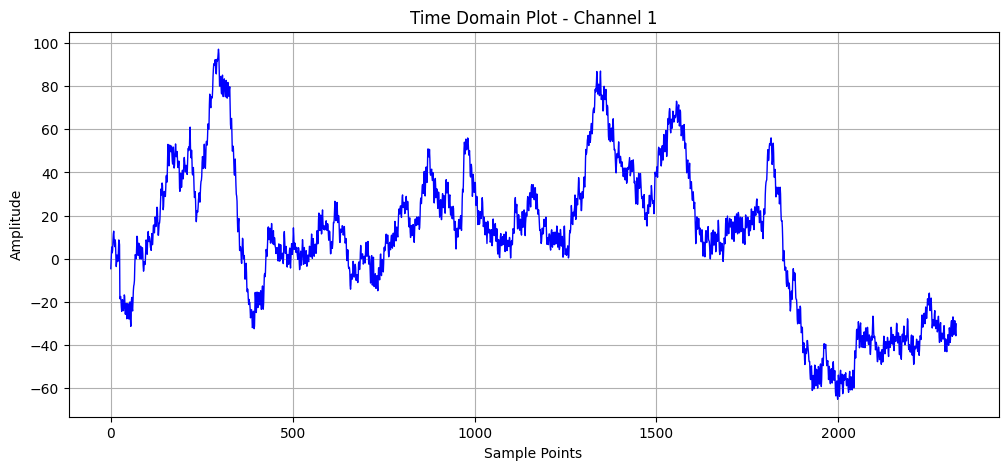

In [5]:
import numpy as np
import matplotlib.pyplot as plt

target_channel = 1 # Select channel index to view (0 to 6)

plt.figure(figsize=(12, 5)) # Set figure size
plt.plot(eeg_data[target_channel, :], color='blue', linewidth=1)
plt.title(f'Time Domain Plot - Channel {target_channel}') # Title
plt.xlabel('Sample Points') # X-axis: sample index
plt.ylabel('Amplitude')     # Y-axis: amplitude
plt.grid(True)              # Show grid
plt.show()                  # Display plot

Applying bandpass filter (1-100Hz)...
number of segs: 9
Start processing data: 7 channels, 9 segments (per segment 250 points)...


c:\Users\36254\anaconda3\envs\neuradock\Lib\site-packages\scipy\signal\_spectral_py.py:600: UserWarning: nperseg = 2048 is greater than input length  = 250, using nperseg = 250
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


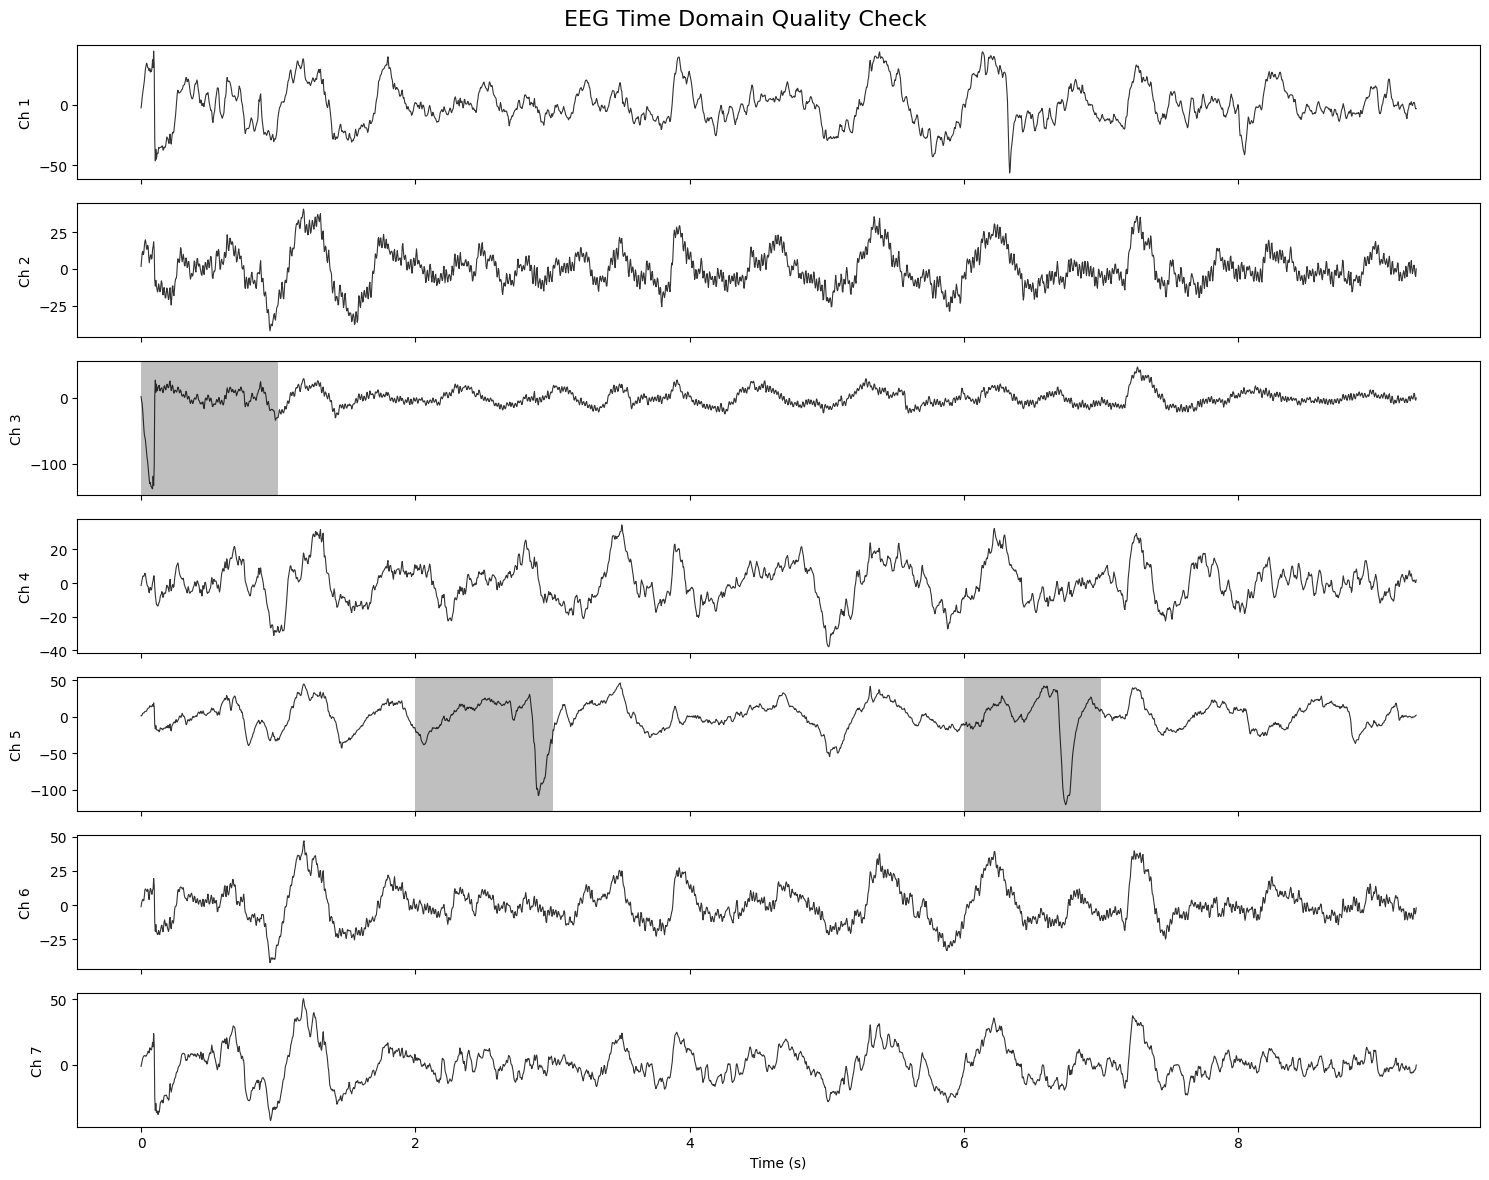

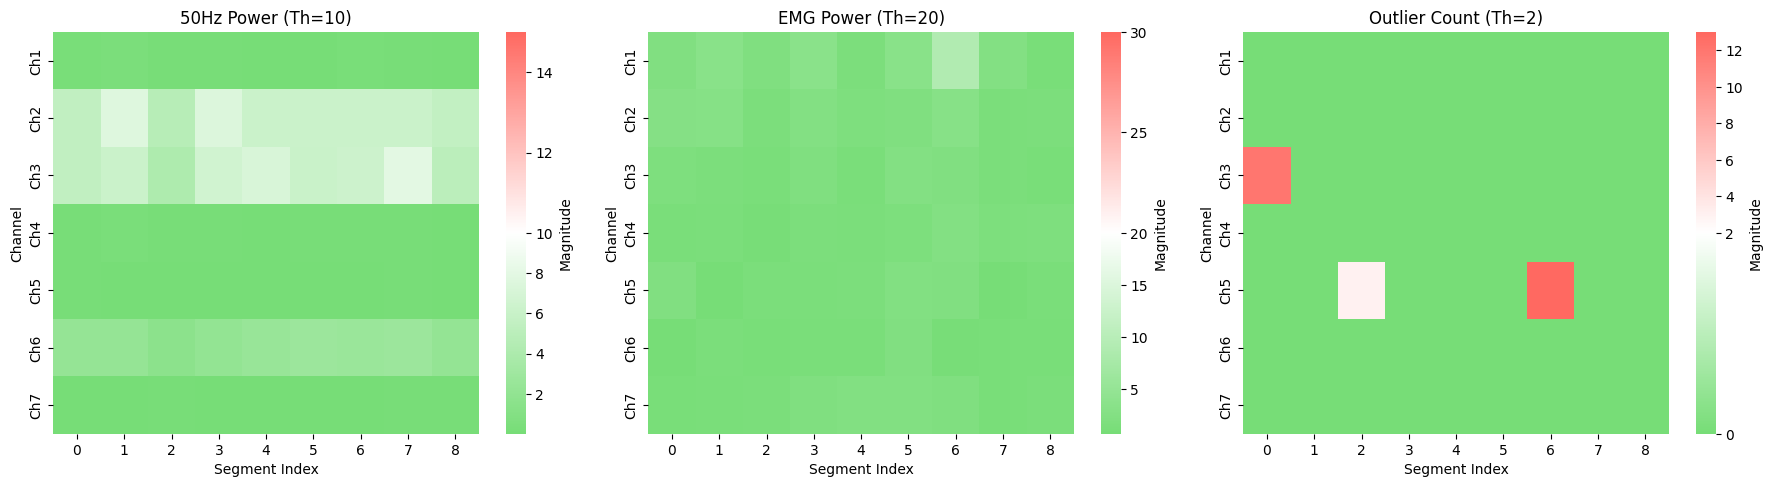


Output matrix shape example (50Hz matrix): (7, 9)


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import signal
import seaborn as sns

def eeg_quality_check(eeg_data, fs=250):
    """
    EEG signal quality check function
    
    Parameters:
    eeg_data: np.array, shape (7, data_points)
    fs: int, sampling rate, default 250
    
    Returns:
    metrics_list: list, containing 4 arrays [power_50hz, power_emg, power_baseline, outlier]
                  each array has shape (7, num_segments)
    """
    
        # ---------------------------------------------------------
    # Modification 1: Bandpass filter (1-100Hz)
    # ---------------------------------------------------------
    print("Applying bandpass filter (1-100Hz)...")
    # 4th-order Butterworth filter (order can be adjusted as needed, typically 2-4 for EEG)
    nyq = 0.5 * fs
    low = 1 / nyq
    high = 100 / nyq
    b, a = signal.butter(4, [low, high], btype='band')
    
    # Use filtfilt for zero-phase filtering to avoid waveform shift
    eeg_data_filtered = signal.filtfilt(b, a, eeg_data, axis=1)
    
    # Subsequent calculations use filtered data
    data = eeg_data_filtered

    n_channels, n_points = data.shape
    seg_len = 250  # Define number of data points per segment N=500
    n_segs = n_points // seg_len # Calculate total number of segments
    print('number of segs:', n_segs)
    # Threshold settings [50Hz, EMG, Outlier]
    thresh = [10, 20,  2]  # this is based on NeuraDock hardware performances, you can modify based on youor application requirements
    
    # Initialize result matrix: shape (7 rows, n_segs columns)
    # Used to store 4 feature values
    res_50hz = np.zeros((n_channels, n_segs))
    res_emg = np.zeros((n_channels, n_segs))
    res_out = np.zeros((n_channels, n_segs))
    
    # 1. Calculate metrics
    print(f"Start processing data: {n_channels} channels, {n_segs} segments (per segment {seg_len} points)...")
    
    for ch in range(n_channels):
        for i in range(n_segs):
            # Get data indices of current segment
            start_idx = i * seg_len
            end_idx = start_idx + seg_len
            segment = data[ch, start_idx:end_idx]
            
            # Calculate Welch PSD (nperseg=2048 as required)
            # Note: when data length (500) < nperseg (2048), scipy will automatically zero-pad
            f, Pxx = signal.welch(segment, fs=fs, nperseg=2048)
            
            # Calculate feature values (according to required logic)
            # 50Hz Power (49-51Hz)
            power_50hz = np.sum(Pxx[np.where((f >= 49) & (f <= 51))])
            
            # EMG Power (20-40Hz)
            power_emg = np.sum(Pxx[np.where((f >= 20) & (f <= 40))])
            
            
            # Outlier Count (<= -50 or >= 50)
            outlier = np.where((segment <= -100) | (segment >= 100))[0].shape[0]
            
            # Store in matrix
            res_50hz[ch, i] = power_50hz
            res_emg[ch, i] = power_emg
            res_out[ch, i] = outlier

    # 2. Visualization - Time domain plot (Subplot 7,1)
    fig_time, axes = plt.subplots(7, 1, figsize=(15, 12), sharex=True)
    fig_time.suptitle('EEG Time Domain Quality Check', fontsize=16)
    
    time_axis = np.arange(n_points) / fs
    
    for ch in range(n_channels):
        ax = axes[ch]
        # Plot raw waveform
        ax.plot(time_axis, data[ch, :], color='black', linewidth=0.8, alpha=0.8)
        ax.set_ylabel(f'Ch {ch+1}')
        
        # Mark noisy segments
        for i in range(n_segs):
            t_start = i * seg_len / fs
            t_end = (i + 1) * seg_len / fs
            
            # Get metrics of current segment
            p50 = res_50hz[ch, i]
            pemg = res_emg[ch, i]
            pout = res_out[ch, i]
            
            # Color marking logic (priority: 50Hz > EMG > Baseline/Outlier)
            # Use axvspan to draw background color
            if p50 > thresh[0]:
                ax.axvspan(t_start, t_end, color='red', alpha=0.3, lw=0)
            elif pemg > thresh[1]:
                ax.axvspan(t_start, t_end, color='blue', alpha=0.3, lw=0)
            elif (pout > thresh[2]):
                ax.axvspan(t_start, t_end, color='gray', alpha=0.5, lw=0)
                
    axes[-1].set_xlabel('Time (s)')
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    
    # 3. Visualization - Heatmaps (4 Heatmaps)
    # ---------------------------------------------------------
    # Modification 2: Heatmap visualization (green-white-red, threshold centered)
    # ---------------------------------------------------------
    fig_heat, axes_heat = plt.subplots(1, 3, figsize=(18, 5))
    
    
    metrics = [res_50hz, res_emg,  res_out]
    titles = [f'50Hz Power (Th={thresh[0]})', 
              f'EMG Power (Th={thresh[1]})', 
              f'Outlier Count (Th={thresh[2]})']
    
    # Custom Colormap: green -> white -> red
    # 0.0=Green, 0.5=White, 1.0=Red
    custom_cmap = mcolors.LinearSegmentedColormap.from_list(
        "GreenWhiteRed", ["#77dd77", "#ffffff", "#ff6961"]
    )
    
    for idx, ax in enumerate(axes_heat.flat):
        current_data = metrics[idx]
        current_thresh = thresh[idx]
        
        # To prevent TwoSlopeNorm errors, ensure vmin < vcenter < vmax
        # Even if all data is above or below threshold, it displays correctly
        d_min = np.min(current_data)
        d_max = np.max(current_data)
        
        # Dynamically set display range to ensure threshold is included
        vmin = min(d_min, current_thresh * 0.5) 
        vmax = max(d_max, current_thresh * 1.5)
        
        if vmin == vmax: # Prevent errors in extreme cases
            vmin -= 0.1
            vmax += 0.1
            
        # Key: TwoSlopeNorm maps vcenter to the middle color (white) of colormap
        norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=current_thresh, vmax=vmax)
        
        sns.heatmap(current_data, ax=ax, 
                    cmap=custom_cmap, 
                    norm=norm,  # Apply normalization
                    cbar=True,
                    cbar_kws={'label': 'Magnitude'},
                    yticklabels=[f'Ch{i+1}' for i in range(n_channels)])
        
        ax.set_title(titles[idx])
        ax.set_xlabel('Segment Index')
        ax.set_ylabel('Channel')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    
    plt.show()

    
    return [res_50hz, res_emg,  res_out],eeg_data_filtered

# ==========================================
# Test code (generate fake data for demonstration)
# ==========================================
if __name__ == "__main__":
    
    # Run check function
    result_arrays ,eeg_data_filtered= eeg_quality_check(eeg_data, 250)
    
    print("\nOutput matrix shape example (50Hz matrix):", result_arrays[0].shape)


Detection results:
  - Bad channel indices (noise ratio > 40.0%): []
  - Good channel indices: [0 1 2 3 4 5 6]
Data cleaning complete: original length 2325 -> cleaned 1575
Information retention rate: 67.74%


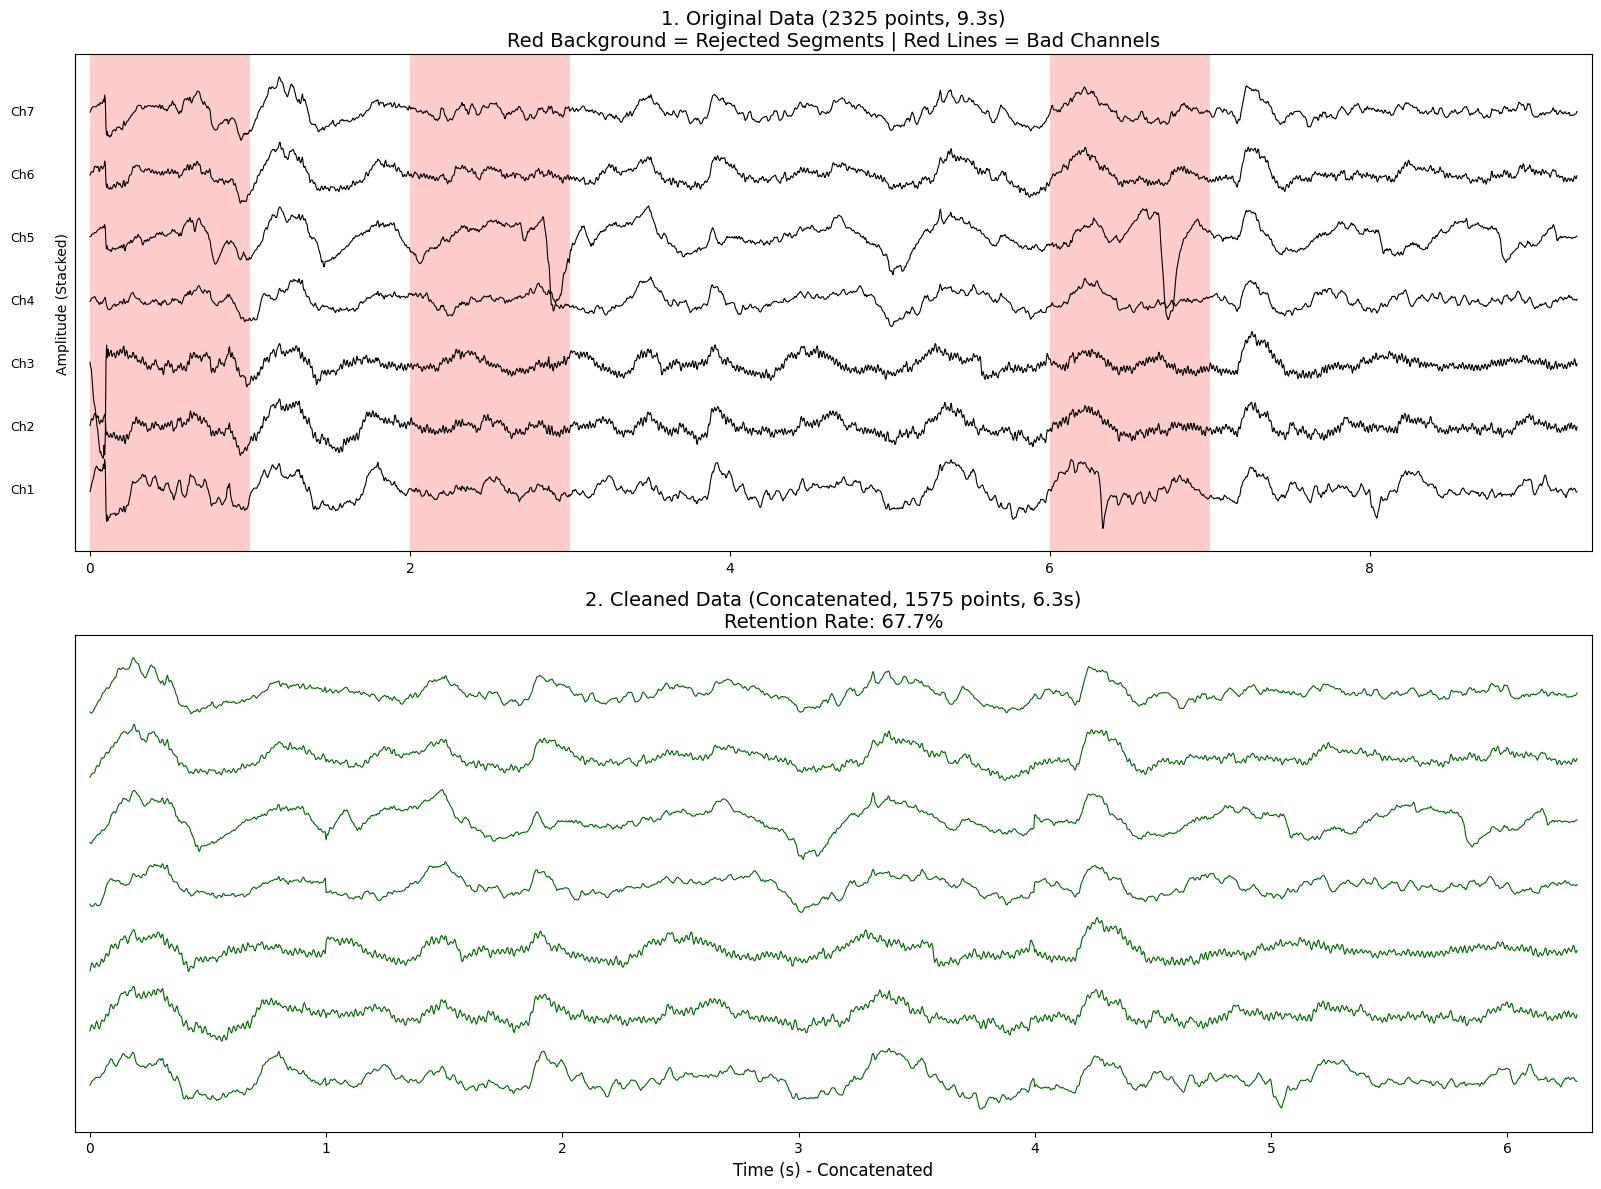

In [7]:
def clean_eeg_data(eeg_data, metrics, thresh, seg_len=250, bad_ch_ratio=0.4):
    """
    Clean EEG data based on quality check results (maximize information retention strategy)
    
    Parameters:
    eeg_data: raw data (7, points)
    metrics: list returned by eeg_quality_check [res_50hz, res_emg, res_out]
    thresh: threshold list [10, 20, 2]
    seg_len: segment length (500)
    bad_ch_ratio: ratio threshold for bad channel detection (default 0.4, i.e., if >40% of time is bad, channel is considered bad)
    
    Returns:
    clean_data: concatenated cleaned data (may be shorter)
    keep_mask: mask of retained data points
    info: dict containing bad channel indices and retention ratio
    """
    
    n_channels, n_points = eeg_data.shape
    n_segs = metrics[0].shape[1]
    
    # 1. Generate combined noise mask (Binary Mask)
    # Shape (7, n_segs), True means the segment for this channel is bad
    # Mark as True if any noise condition is met
    mask_50hz = metrics[0] > thresh[0]
    mask_emg  = metrics[1] > thresh[1]
    mask_out  = metrics[2] > thresh[2]
    
    total_noise_mask = mask_50hz | mask_emg | mask_out
    
    # -----------------------------------------------------------
    # Step 1: Identify and isolate "bad channels" (Bad Channels)
    # -----------------------------------------------------------
    # Calculate bad segment ratio for each channel
    bad_seg_counts = np.sum(total_noise_mask, axis=1) # How many bad segments each channel has
    bad_ratios = bad_seg_counts / n_segs
    
    # If bad segment ratio > 40%, mark as bad channel
    bad_channel_indices = np.where(bad_ratios > bad_ch_ratio)[0]
    good_channel_indices = np.where(bad_ratios <= bad_ch_ratio)[0]
    
    print(f"Detection results:")
    print(f"  - Bad channel indices (noise ratio > {bad_ch_ratio*100}%): {bad_channel_indices}")
    print(f"  - Good channel indices: {good_channel_indices}")
    
    # -----------------------------------------------------------
    # Step 2: Based on "good channels", decide which time segments to remove
    # -----------------------------------------------------------
    # We only look at noise in good channels. If good channels also have noise, it indicates subject movement or large interference
    if len(good_channel_indices) > 0:
        # Extract mask for good channels only
        good_ch_mask = total_noise_mask[good_channel_indices, :]
        # In this segment, if any good channel is bad, we consider this segment unusable
        # (axis=0 performs 'OR', i.e., if any True in column direction, the segment is True)
        segments_to_reject = np.any(good_ch_mask, axis=0)
    else:
        # Extreme case: all channels are bad, keep all segments or delete all
        # Here choose to keep all segments, but reflect in bad channel list
        print("Warning: all channels are marked as bad!")
        segments_to_reject = np.zeros(n_segs, dtype=bool)

    # -----------------------------------------------------------
    # 3. Physically delete/splice data
    # -----------------------------------------------------------
    # Expand segment mask (n_segs,) back to point mask (n_points,)
    # np.repeat: [0, 1] -> [0,0,0... , 1,1,1...]
    points_to_reject = np.repeat(segments_to_reject, seg_len)
    
    # Handle case where data length is not divisible by seg_len (pad)
    if len(points_to_reject) < n_points:
        padding = np.zeros(n_points - len(points_to_reject), dtype=bool)
        points_to_reject = np.concatenate([points_to_reject, padding])
    elif len(points_to_reject) > n_points:
        points_to_reject = points_to_reject[:n_points]
        
    points_to_keep = ~points_to_reject
    
    # Perform deletion (only keep columns where mask is True)
    clean_data = eeg_data[:, points_to_keep]
    
    # -----------------------------------------------------------
    # 4. (Optional) Simple bad channel repair: fill bad channels with 0
    # -----------------------------------------------------------
    # Note: More advanced method is spherical spline interpolation,
    # but that requires electrode coordinates. Here to keep data shape, if not deleting channels, usually set to zero or keep original.
    # Here we choose to keep original, but inform user in returned info.
    
    retention_rate = clean_data.shape[1] / n_points
    print(f"Data cleaning complete: original length {n_points} -> cleaned {clean_data.shape[1]}")
    print(f"Information retention rate: {retention_rate:.2%}")
    
    info = {
        'bad_channels': bad_channel_indices,
        'retention_rate': retention_rate,
        'rejected_segments_count': np.sum(segments_to_reject)
    }
    
    return clean_data, points_to_keep, info
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# =========================================================
# Auxiliary function: find continuous False regions (for drawing red background)
# =========================================================
def find_rejected_intervals(mask):
    """
    Input: bool mask (True=Keep, False=Reject)
    Output: list of tuples [(start_idx, end_idx), ...]
    """
    # Pad boundaries to handle cases rejected at beginning or end
    padded_mask = np.concatenate(([True], mask, [True]))
    # Find state transition points (True -> False or False -> True)
    diff = np.diff(padded_mask.astype(int))
    
    # -1 means True to False (rejection start)
    # 1 means False to True (rejection end)
    starts = np.where(diff == -1)[0]
    ends = np.where(diff == 1)[0]
    
    return list(zip(starts, ends))

# =========================================================
# Core visualization function
# =========================================================
def visualize_cleaning_comparison(raw_data, clean_data, keep_mask, info, fs=250):
    """
    Draw professional comparison plot: raw data vs cleaned data
    Plot in stacked (waterfall) style to avoid overlap.
    """
    n_channels = raw_data.shape[0]
    bad_channels = info['bad_channels']
    
    # Calculate Y-axis offset to prevent channel overlap
    # Use 5 times data standard deviation as channel spacing
    std_val = np.std(raw_data)
    offset_step = std_val * 6 
    
    # Create time axis
    t_raw = np.arange(raw_data.shape[1]) / fs
    t_clean = np.arange(clean_data.shape[1]) / fs
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=False)
    
    # -----------------------------------------------------
    # Subplot 1: Original data (mark rejected regions and bad channels)
    # -----------------------------------------------------
    ax1.set_title(f"1. Original Data ({raw_data.shape[1]} points, {raw_data.shape[1]/fs:.1f}s)\n"
                  f"Red Background = Rejected Segments | Red Lines = Bad Channels", fontsize=14)
    
    # 1.1 Draw red background (rejected time segments)
    intervals = find_rejected_intervals(keep_mask)
    for start, end in intervals:
        ax1.axvspan(start/fs, end/fs, color='red', alpha=0.2, lw=0)
    
    # 1.2 Plot waveform for each channel
    for ch in range(n_channels):
        # Calculate Y-axis position for current channel
        y_offset = ch * offset_step
        trace = raw_data[ch, :] + y_offset
        
        # Determine if bad channel
        if ch in bad_channels:
            # Bad channels use red dashed line, slightly lighter
            ax1.plot(t_raw, trace, color='red', linewidth=1, linestyle='--', alpha=0.6)
            # Mark "BAD" on left Y-axis
            ax1.text(t_raw[0]-0.5, y_offset, f"BAD Ch{ch+1}", color='red', 
                     fontsize=9, verticalalignment='center', fontweight='bold')
        else:
            # Good channels use black solid line
            ax1.plot(t_raw, trace, color='black', linewidth=0.8)
            ax1.text(t_raw[0]-0.5, y_offset, f"Ch{ch+1}", color='black', 
                     fontsize=9, verticalalignment='center')

    ax1.set_ylabel("Amplitude (Stacked)")
    ax1.set_yticks([]) # Hide Y-axis ticks because offset is already applied
    ax1.margins(x=0.01)
    
    # -----------------------------------------------------
    # Subplot 2: Cleaned data (concatenated result)
    # -----------------------------------------------------
    ax2.set_title(f"2. Cleaned Data (Concatenated, {clean_data.shape[1]} points, {clean_data.shape[1]/fs:.1f}s)\n"
                  f"Retention Rate: {info['retention_rate']:.1%}", fontsize=14)
    
    for ch in range(n_channels):
        y_offset = ch * offset_step
        trace = clean_data[ch, :] + y_offset
        
        if ch in bad_channels:
            # In cleaned data, bad channels still exist (just shorter), still marked in red
            # In actual analysis, this channel should be discarded or interpolated
            ax2.plot(t_clean, trace, color='red', linewidth=0.5, alpha=0.3)
        else:
            # Retained good data uses dark green, indicating "Clean"
            ax2.plot(t_clean, trace, color='#006400', linewidth=0.8)

    ax2.set_xlabel("Time (s) - Concatenated", fontsize=12)
    ax2.set_yticks([])
    ax2.margins(x=0.01)

    plt.tight_layout()
    plt.show()
# =======================================================
# Usage example (following previous code)
# =======================================================
if __name__ == "__main__":
    # Assume you have run eeg_quality_check and obtained metrics
    # metrics = [res_50hz, res_emg, res_out]
    # raw_data is the raw data
    
    # Define previous thresholds
    current_thresh = [10, 20, 2] 
    
    # Run cleaning
    cleaned_data, mask, info = clean_eeg_data(eeg_data_filtered, result_arrays, current_thresh, seg_len=250)
    # Visualize comparison
    visualize_cleaning_comparison(eeg_data_filtered, cleaned_data, mask, info, 250)
    
